In [1]:
#Author-Sunil Yadav
#Here, I made code to convert Solo-Burst mode mag data from RTN to MVA Co-ordinates.

In [12]:
import numpy as np
import cdflib
from spacepy import pycdf
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Shock normal: [0.90166436 0.23979473 0.3598609 ]
Reliability: 5.843576069881303


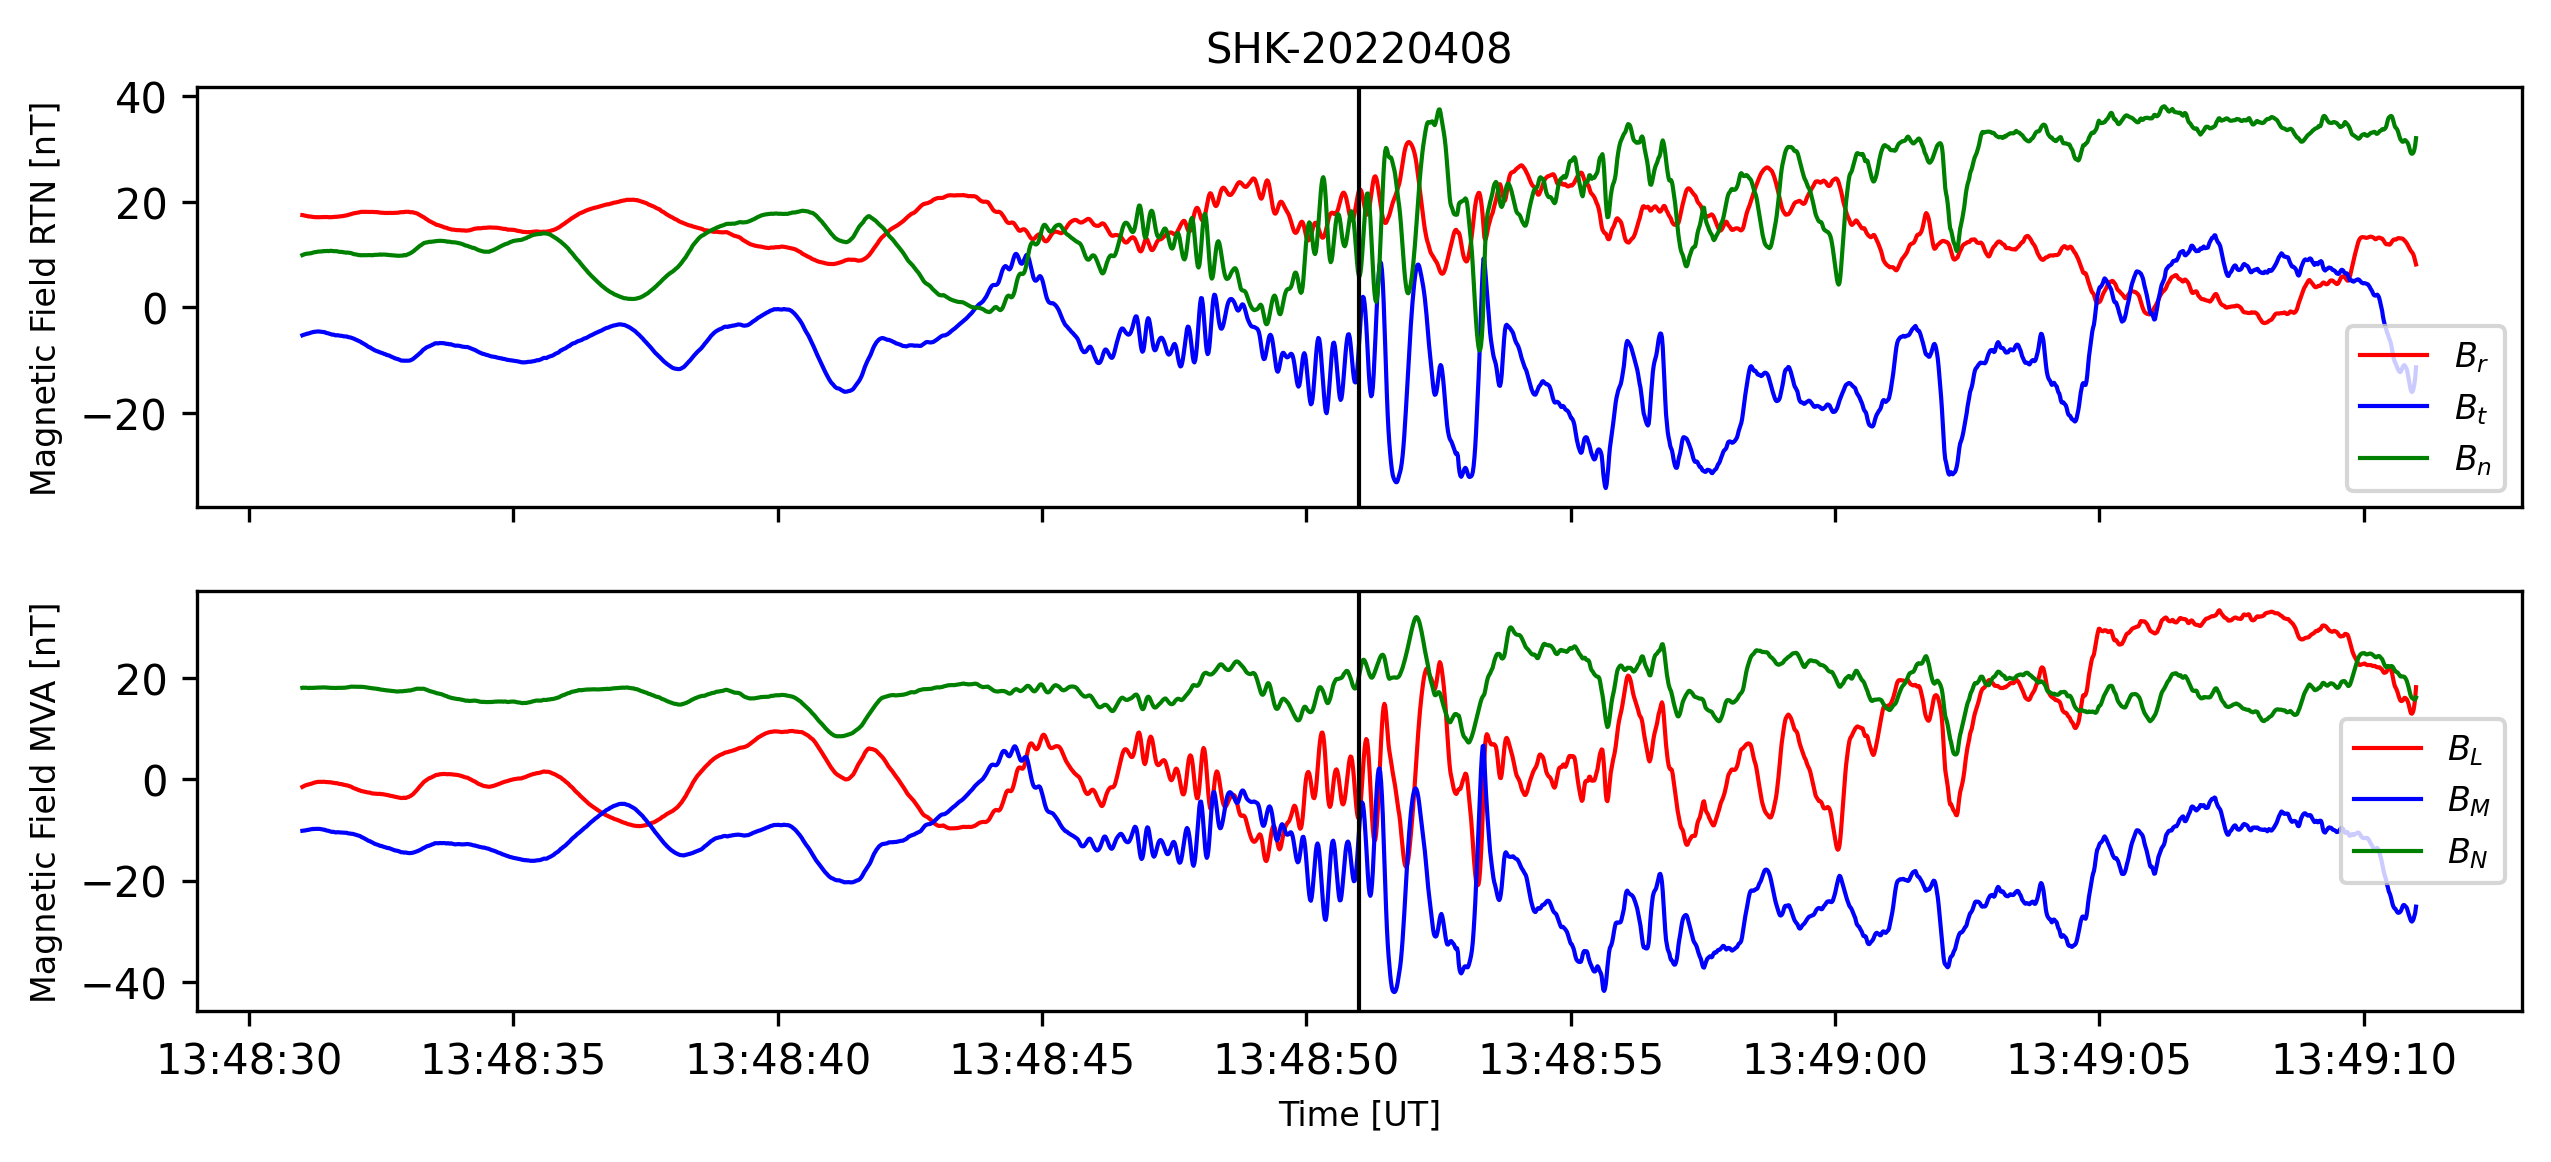

In [26]:
#Load Magnetic field data from Solo-Burst mode CDF file RTN co-ordinates
Data = cdflib.CDF(r"C:\Sunil\USB Drive\download_new\Finland\Data\MAG_Burst_Dis_Shock_list\solo_l2_mag-rtn-burst_20220408_v02.cdf")

#Define shock time- Here I use SERPENTINE as a reference to find out the shock time
s_time = dt.datetime(2022, 4, 8, 13, 48, 51)  # Shock time in UTC

#Magnetic field data
B = Data.varget('B_RTN')
B = np.nan_to_num(B)  # Convert NaN to zero
# Step-1: Magnetic field components
Bmag_rtn = np.linalg.norm(B, axis=1)
Br = B[:, 0]
Bt = B[:, 1]
Bn = B[:, 2]

Time = Data.varget('EPOCH')
time_mag = cdflib.cdfepoch.to_datetime(Time)

# Step-2: Here I extract shock trasition magnetic field
t_start = s_time - dt.timedelta(seconds=20)
t_end   = s_time + dt.timedelta(seconds=20)

#define a function to window the data
def window_size(time, Data, t1, t2):
    t1 = np.datetime64(t1, 'ns')
    t2 = np.datetime64(t2, 'ns')
    idx = (time >= t1) & (time <= t2)
    return Data[idx]

B_s = window_size(time_mag, B, t_start, t_end)

##============================
# MVA Calculation
##============================
# step-3: mean
B_mean = np.mean(B_s,axis = 0)

# step-4: Define fluctuations
dB = B_s - B_mean

# step-5: Variance matrix
Var = np.cov(dB.T)

# step-6: Eigenvalue and Eigenvector
Egvalue, Egvect = np.linalg.eigh(Var)

idx = np.argsort(Egvalue)

lambda_min = Egvalue[idx[0]]
lambda_int = Egvalue[idx[1]]
lambda_max = Egvalue[idx[2]]


L = Egvect[:, idx[2]]
M = Egvect[:, idx[1]]   
N = Egvect[:, idx[0]]

print("Shock normal:", N)

print("Reliability:",
lambda_int/lambda_min)

# Ensure right-handed system
#if np.dot(np.cross(L, M), N) > 0:
#    N = -N

# Transformation matrix
Mtx = np.column_stack((L,M,N))

##============================
# RTN to MVA co-ordinates
##============================
#Transform magnetic field data from RTN to MVA co-ordinates
B_lmn = np.dot(B, Mtx)

BL = B_lmn[:, 0]
BM = B_lmn[:, 1]    
BN = B_lmn[:, 2]

Bmag_lmn = np.sqrt(BL**2 + BM**2 + BN**2)

#Save the MVA transformed data in a new CDF file

output_file = r"C:\Sunil\USB Drive\download_new\Finland\Data\MAG_Burst_Dis_Shock_list_MVA_cord\solo_l2_mag-mva-burst_20220408_v01.cdf"

with pycdf.CDF(output_file, create=True) as cdf:
    cdf['EPOCH'] = Time
    cdf['B_L'] = BL
    cdf['B_M'] = BM
    cdf['B_N'] = BN
    cdf['B_MAG_LMN'] = Bmag_lmn

    cdf['B_L'].attrs['units'] = 'nT'
    cdf['B_M'].attrs['units'] = 'nT'    
    cdf['B_N'].attrs['units'] = 'nT'
    cdf['B_MAG_LMN'].attrs['units'] = 'nT'  

#Plot RTN and MVA co-ordinates

# Here I choose magnetic field within -10 min to +10 min
t_start = s_time - dt.timedelta(seconds = 20)
t_end   = s_time + dt.timedelta(seconds = 20)

B_rtn = window_size(time_mag, B, t_start, t_end)
B_mva = window_size(time_mag, B_lmn, t_start, t_end)
time = window_size(time_mag,time_mag,t_start,t_end)

#Magnetic field components in RTN and MVA co-ordinates
Bmag = np.linalg.norm(B_rtn, axis=1)
Br = B_rtn[:, 0]
Bt = B_rtn[:, 1]
Bn = B_rtn[:, 2]
BL = B_mva[:, 0]
BM = B_mva[:, 1]
BN = B_mva[:, 2]
Bmag_mva = np.linalg.norm(B_mva, axis=1)

fig, axs = plt.subplots(2, 1, figsize=(10, 4), dpi=300, sharex=True)
axs[0].plot(time, Br, label=r'$B_{r}$', color='red', linewidth=1)
axs[0].plot(time, Bt, label=r'$B_{t}$', color='blue', linewidth=1)
axs[0].plot(time, Bn, label=r'$B_{n}$', color='green', linewidth=1)
axs[0].set_ylabel("Magnetic Field RTN [nT]", fontsize = 8)
axs[0].set_title('SHK-20220408', fontsize=10)
axs[0].axvline(s_time,color='black',linewidth=1)
axs[0].legend(fontsize=8)
axs[1].plot(time, BL, label=r'$B_{L}$', color='red', linewidth=1)
axs[1].plot(time, BM, label=r'$B_{M}$', color='blue', linewidth=1)
axs[1].plot(time, BN, label=r'$B_{N}$', color='green', linewidth=1)
axs[1].set_ylabel("Magnetic Field MVA [nT]", fontsize = 8)
plt.xlabel('Time [UT]', fontsize=8)
axs[1].axvline(s_time,color='black',linewidth=1)
axs[1].legend(fontsize=8)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.savefig('Magnetic field SHK(20220408)_RTN_MVA (-20to+20sec)_Dispersive_Nature', bbox_inches='tight')
plt.show()



In [25]:
B.shape

(5529656, 3)